# Letras griegas

En este documento se detalla el calculo de griegas para opciones call y put.


## Put

In [62]:
import pandas as pd
import numpy as np

from scipy.optimize import brentq
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [63]:
start_date = "2026-01-17"
end_date = "2026-04-28"

In [64]:
def _validate_option_inputs(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    volatility: float,
    require_positive_time_and_volatility: bool = False,
) -> None:
    if spot_price <= 0:
        raise ValueError("spot_price debe ser mayor que 0.")
    if strike_price <= 0:
        raise ValueError("strike_price debe ser mayor que 0.")
    if time_to_maturity < 0:
        raise ValueError("time_to_maturity no puede ser negativo.")
    if volatility < 0:
        raise ValueError("volatility no puede ser negativa.")

    if require_positive_time_and_volatility:
        if time_to_maturity <= 0:
            raise ValueError(
                "time_to_maturity debe ser mayor que 0 para calcular griegas."
            )
        if volatility <= 0:
            raise ValueError("volatility debe ser mayor que 0 para calcular griegas.")


def _discount_factor(rate: float, time_to_maturity: float) -> float:
    return np.exp(-rate * time_to_maturity)


def _discounted_spot(
    spot_price: float,
    time_to_maturity: float,
    dividend_yield: float,
) -> float:
    return spot_price * _discount_factor(dividend_yield, time_to_maturity)


def _discounted_strike(
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
) -> float:
    return strike_price * _discount_factor(risk_free_rate, time_to_maturity)


def _forward_price(
    spot_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    dividend_yield: float,
) -> float:
    return spot_price * np.exp((risk_free_rate - dividend_yield) * time_to_maturity)


def d1(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    _validate_option_inputs(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        volatility=volatility,
        require_positive_time_and_volatility=True,
    )

    sqrt_time = np.sqrt(time_to_maturity)
    numerator = np.log(spot_price / strike_price) + (
        risk_free_rate - dividend_yield + 0.5 * volatility**2
    ) * time_to_maturity

    return numerator / (volatility * sqrt_time)


def d2(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    return d1(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    ) - volatility * np.sqrt(time_to_maturity)


def _black_scholes_terms(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float,
) -> tuple[float, float]:
    d1_value = d1(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    d2_value = d1_value - volatility * np.sqrt(time_to_maturity)

    return d1_value, d2_value


def european_put_price(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    """
    Calcula el precio de un put europeo con el modelo de Black-Scholes.
    """
    _validate_option_inputs(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        volatility=volatility,
    )

    if time_to_maturity == 0:
        return float(max(strike_price - spot_price, 0.0))

    if volatility == 0:
        forward_price = _forward_price(
            spot_price=spot_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
        )
        discounted_payoff = _discount_factor(risk_free_rate, time_to_maturity) * max(
            strike_price - forward_price,
            0.0,
        )
        return float(discounted_payoff)

    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    put_price = (
        _discounted_strike(strike_price, time_to_maturity, risk_free_rate)
        * norm.cdf(-d2_value)
        - _discounted_spot(spot_price, time_to_maturity, dividend_yield)
        * norm.cdf(-d1_value)
    )

    return float(put_price)


def put_delta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    return float(-_discount_factor(dividend_yield, time_to_maturity) * norm.cdf(-d1_value))


def put_gamma(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_density = _discount_factor(dividend_yield, time_to_maturity) * norm.pdf(
        d1_value
    )

    return float(discounted_density / (spot_price * volatility * np.sqrt(time_to_maturity)))


def put_theta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    theta_value = (
        -discounted_spot * norm.pdf(d1_value) * volatility / (2 * np.sqrt(time_to_maturity))
        + risk_free_rate * discounted_strike * norm.cdf(-d2_value)
        - dividend_yield * discounted_spot * norm.cdf(-d1_value)
    )

    return float(theta_value)


def put_rho(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    _, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    return float(-time_to_maturity * discounted_strike * norm.cdf(-d2_value))


def put_vega(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)

    return float(discounted_spot * norm.pdf(d1_value) * np.sqrt(time_to_maturity))


delta = put_delta
gamma = put_gamma
theta = put_theta
rho = put_rho
vega = put_vega


## Call

In [65]:
def european_call_price(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    """
    Calcula el precio de un call europeo con el modelo de Black-Scholes.
    """
    _validate_option_inputs(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        volatility=volatility,
    )

    if time_to_maturity == 0:
        return float(max(spot_price - strike_price, 0.0))

    if volatility == 0:
        forward_price = _forward_price(
            spot_price=spot_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
        )
        discounted_payoff = _discount_factor(risk_free_rate, time_to_maturity) * max(
            forward_price - strike_price,
            0.0,
        )
        return float(discounted_payoff)

    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    call_price = (
        _discounted_spot(spot_price, time_to_maturity, dividend_yield)
        * norm.cdf(d1_value)
        - _discounted_strike(strike_price, time_to_maturity, risk_free_rate)
        * norm.cdf(d2_value)
    )

    return float(call_price)


def call_delta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )

    return float(_discount_factor(dividend_yield, time_to_maturity) * norm.cdf(d1_value))


def call_gamma(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_density = _discount_factor(dividend_yield, time_to_maturity) * norm.pdf(
        d1_value
    )

    return float(discounted_density / (spot_price * volatility * np.sqrt(time_to_maturity)))


def call_theta(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    theta_value = (
        -discounted_spot * norm.pdf(d1_value) * volatility / (2 * np.sqrt(time_to_maturity))
        - risk_free_rate * discounted_strike * norm.cdf(d2_value)
        + dividend_yield * discounted_spot * norm.cdf(d1_value)
    )

    return float(theta_value)


def call_rho(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    _, d2_value = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_strike = _discounted_strike(
        strike_price,
        time_to_maturity,
        risk_free_rate,
    )

    return float(time_to_maturity * discounted_strike * norm.cdf(d2_value))


def call_vega(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    dividend_yield: float = 0.0,
) -> float:
    d1_value, _ = _black_scholes_terms(
        spot_price=spot_price,
        strike_price=strike_price,
        time_to_maturity=time_to_maturity,
        risk_free_rate=risk_free_rate,
        volatility=volatility,
        dividend_yield=dividend_yield,
    )
    discounted_spot = _discounted_spot(spot_price, time_to_maturity, dividend_yield)

    return float(discounted_spot * norm.pdf(d1_value) * np.sqrt(time_to_maturity))


## Greek utils


In [66]:
DEFAULT_RISK_FREE_RATE = 0.05
DEFAULT_DIVIDEND_YIELD = 0.0
DEFAULT_VOLATILITY = 0.20
MIN_IMPLIED_VOLATILITY = 1e-4
MAX_IMPLIED_VOLATILITY = 5.0
TRADING_DAYS = 252

GREEK_COLUMNS = ["bs_price", "delta", "gamma", "theta", "rho", "vega"]


def prepare_option_data(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data["expiration_date"] = pd.to_datetime(
        data["expiration_date"],
        errors="coerce",
    )
    data["snapshot_utc"] = pd.to_datetime(
        data["snapshot_utc"],
        utc=True,
        errors="coerce",
    )
    data["option_type"] = data["option_type"].astype(str).str.lower()

    numeric_columns = [
        "strike",
        "last_price",
        "bid",
        "ask",
        "mid",
        "underlying_price",
        "implied_volatility",
    ]
    for column in numeric_columns:
        if column in data.columns:
            data[column] = pd.to_numeric(data[column], errors="coerce")

    if "mid" not in data.columns:
        data["mid"] = (data["bid"] + data["ask"]) / 2

    data["market_price"] = data["mid"].where(data["mid"] > 0, data["last_price"])
    data["time_to_maturity"] = (
        data["expiration_date"] - data["date"]
    ).dt.days / 365.0

    return data


def estimate_annual_volatility(
    df: pd.DataFrame,
    price_col: str = "underlying_price",
) -> float:
    prices = (
        df[["date", price_col]]
        .dropna()
        .drop_duplicates("date")
        .sort_values("date")
    )
    returns = prices[price_col].pct_change().dropna()

    if returns.empty:
        return np.nan

    volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    if not np.isfinite(volatility) or volatility <= 0:
        return np.nan

    return float(volatility)


def black_scholes_price(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    volatility: float,
    option_type: str,
    dividend_yield: float = DEFAULT_DIVIDEND_YIELD,
) -> float:
    option_type = option_type.lower()

    if option_type == "call":
        return european_call_price(
            spot_price=spot_price,
            strike_price=strike_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            volatility=volatility,
            dividend_yield=dividend_yield,
        )

    if option_type == "put":
        return european_put_price(
            spot_price=spot_price,
            strike_price=strike_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            volatility=volatility,
            dividend_yield=dividend_yield,
        )

    raise ValueError("option_type debe ser 'call' o 'put'.")


def calculate_implied_volatility(
    spot_price: float,
    strike_price: float,
    time_to_maturity: float,
    risk_free_rate: float,
    market_price: float,
    option_type: str,
    dividend_yield: float = DEFAULT_DIVIDEND_YIELD,
    min_volatility: float = MIN_IMPLIED_VOLATILITY,
    max_volatility: float = MAX_IMPLIED_VOLATILITY,
) -> float:
    inputs = [spot_price, strike_price, time_to_maturity, market_price]
    if any(not np.isfinite(value) for value in inputs):
        return np.nan
    if spot_price <= 0 or strike_price <= 0 or time_to_maturity <= 0:
        return np.nan
    if market_price <= 0:
        return np.nan

    def pricing_error(volatility: float) -> float:
        return black_scholes_price(
            spot_price=spot_price,
            strike_price=strike_price,
            time_to_maturity=time_to_maturity,
            risk_free_rate=risk_free_rate,
            volatility=volatility,
            option_type=option_type,
            dividend_yield=dividend_yield,
        ) - market_price

    low_error = pricing_error(min_volatility)
    high_error = pricing_error(max_volatility)

    if abs(low_error) < 1e-8:
        return min_volatility
    if abs(high_error) < 1e-8:
        return max_volatility
    if low_error * high_error > 0:
        return np.nan

    return float(
        brentq(
            pricing_error,
            min_volatility,
            max_volatility,
            xtol=1e-8,
            maxiter=100,
        )
    )


def calculate_implied_volatility_series(
    df: pd.DataFrame,
    risk_free_rate: float,
    dividend_yield: float,
) -> pd.Series:
    implied_values = [
        calculate_implied_volatility(
            spot_price=row.underlying_price,
            strike_price=row.strike,
            time_to_maturity=row.time_to_maturity,
            risk_free_rate=risk_free_rate,
            market_price=row.market_price,
            option_type=row.option_type,
            dividend_yield=dividend_yield,
        )
        for row in df.itertuples(index=False)
    ]

    return pd.Series(implied_values, index=df.index, dtype="float64")


def _resolve_volatility(
    df: pd.DataFrame,
    risk_free_rate: float,
    dividend_yield: float,
    volatility: float | None,
    fallback_volatility: float,
    use_market_implied_volatility: bool,
    fill_missing_implied_volatility: bool,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    if volatility is not None:
        constant_volatility = pd.Series(float(volatility), index=df.index)
        source = pd.Series("manual", index=df.index)
        return constant_volatility, constant_volatility.copy(), source

    market_implied = calculate_implied_volatility_series(
        df=df,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
    )

    if use_market_implied_volatility:
        volatility_used = market_implied.copy()
        source = pd.Series("market_implied", index=df.index)
        source = source.where(volatility_used.notna(), "missing_implied")

        if fill_missing_implied_volatility:
            historical_volatility = estimate_annual_volatility(df)
            fallback = (
                historical_volatility
                if np.isfinite(historical_volatility)
                else fallback_volatility
            )
            volatility_used = volatility_used.fillna(fallback)
            source = source.where(market_implied.notna(), "fallback")

        return volatility_used, market_implied, source

    historical_volatility = estimate_annual_volatility(df)
    fallback = (
        historical_volatility
        if np.isfinite(historical_volatility)
        else fallback_volatility
    )
    volatility_used = pd.Series(fallback, index=df.index)
    source = pd.Series("historical", index=df.index)

    return volatility_used, market_implied, source


def add_option_greeks(
    df: pd.DataFrame,
    risk_free_rate: float = DEFAULT_RISK_FREE_RATE,
    volatility: float | None = None,
    dividend_yield: float = DEFAULT_DIVIDEND_YIELD,
    fallback_volatility: float = DEFAULT_VOLATILITY,
    use_market_implied_volatility: bool = True,
    fill_missing_implied_volatility: bool = False,
) -> pd.DataFrame:
    data = prepare_option_data(df)
    vol, market_implied_volatility, volatility_source = _resolve_volatility(
        df=data,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
        volatility=volatility,
        fallback_volatility=fallback_volatility,
        use_market_implied_volatility=use_market_implied_volatility,
        fill_missing_implied_volatility=fill_missing_implied_volatility,
    )

    spot = data["underlying_price"].to_numpy(dtype=float)
    strike = data["strike"].to_numpy(dtype=float)
    time = data["time_to_maturity"].to_numpy(dtype=float)
    sigma = vol.to_numpy(dtype=float)
    option_type = data["option_type"].to_numpy(dtype=str)

    valid = (
        (spot > 0)
        & (strike > 0)
        & (time > 0)
        & (sigma > 0)
        & np.isfinite(spot)
        & np.isfinite(strike)
        & np.isfinite(time)
        & np.isfinite(sigma)
    )

    d1_values = np.full(len(data), np.nan)
    d2_values = np.full(len(data), np.nan)
    bs_price = np.full(len(data), np.nan)
    delta = np.full(len(data), np.nan)
    gamma = np.full(len(data), np.nan)
    theta = np.full(len(data), np.nan)
    rho = np.full(len(data), np.nan)
    vega = np.full(len(data), np.nan)

    sqrt_time = np.sqrt(time[valid])
    d1_values[valid] = (
        np.log(spot[valid] / strike[valid])
        + (risk_free_rate - dividend_yield + 0.5 * sigma[valid] ** 2) * time[valid]
    ) / (sigma[valid] * sqrt_time)
    d2_values[valid] = d1_values[valid] - sigma[valid] * sqrt_time

    discount_spot = spot * np.exp(-dividend_yield * time)
    discount_strike = strike * np.exp(-risk_free_rate * time)
    density = norm.pdf(d1_values)

    call_mask = valid & (option_type == "call")
    put_mask = valid & (option_type == "put")

    bs_price[call_mask] = (
        discount_spot[call_mask] * norm.cdf(d1_values[call_mask])
        - discount_strike[call_mask] * norm.cdf(d2_values[call_mask])
    )
    bs_price[put_mask] = (
        discount_strike[put_mask] * norm.cdf(-d2_values[put_mask])
        - discount_spot[put_mask] * norm.cdf(-d1_values[put_mask])
    )

    delta[call_mask] = np.exp(-dividend_yield * time[call_mask]) * norm.cdf(
        d1_values[call_mask]
    )
    delta[put_mask] = -np.exp(-dividend_yield * time[put_mask]) * norm.cdf(
        -d1_values[put_mask]
    )

    gamma[valid] = (
        np.exp(-dividend_yield * time[valid])
        * density[valid]
        / (spot[valid] * sigma[valid] * np.sqrt(time[valid]))
    )

    vega[valid] = discount_spot[valid] * density[valid] * np.sqrt(time[valid])

    theta[call_mask] = (
        -discount_spot[call_mask]
        * density[call_mask]
        * sigma[call_mask]
        / (2 * np.sqrt(time[call_mask]))
        - risk_free_rate * discount_strike[call_mask] * norm.cdf(d2_values[call_mask])
        + dividend_yield * discount_spot[call_mask] * norm.cdf(d1_values[call_mask])
    )
    theta[put_mask] = (
        -discount_spot[put_mask]
        * density[put_mask]
        * sigma[put_mask]
        / (2 * np.sqrt(time[put_mask]))
        + risk_free_rate * discount_strike[put_mask] * norm.cdf(-d2_values[put_mask])
        - dividend_yield * discount_spot[put_mask] * norm.cdf(-d1_values[put_mask])
    )

    rho[call_mask] = time[call_mask] * discount_strike[call_mask] * norm.cdf(
        d2_values[call_mask]
    )
    rho[put_mask] = -time[put_mask] * discount_strike[put_mask] * norm.cdf(
        -d2_values[put_mask]
    )

    data["risk_free_rate_used"] = risk_free_rate
    data["dividend_yield_used"] = dividend_yield
    data["market_implied_volatility"] = market_implied_volatility
    data["volatility_used"] = vol
    data["volatility_source"] = volatility_source
    data["d1"] = d1_values
    data["d2"] = d2_values
    data["bs_price"] = bs_price
    data["delta"] = delta
    data["gamma"] = gamma
    data["theta"] = theta
    data["rho"] = rho
    data["vega"] = vega

    return data


def select_contract_history(
    df: pd.DataFrame,
    expiration_date: str,
    option_type: str,
    strike: float,
) -> pd.DataFrame:
    expiration = pd.Timestamp(expiration_date)
    option_type = option_type.lower()

    mask = (
        df["expiration_date"].dt.normalize().eq(expiration)
        & df["option_type"].eq(option_type)
        & df["strike"].eq(float(strike))
    )

    return df.loc[mask].sort_values("date").reset_index(drop=True)


def plot_greek_history(
    df_call: pd.DataFrame,
    df_put: pd.DataFrame,
    greek: str,
    title: str,
) -> None:
    plt.figure(figsize=(9, 5))
    plt.plot(df_call["date"], df_call[greek], marker="o", label="Call")
    plt.plot(df_put["date"], df_put[greek], marker="o", label="Put")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(greek.title())
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def _latest_contract_row(df: pd.DataFrame) -> pd.Series:
    return df.dropna(subset=["time_to_maturity", "volatility_used"]).sort_values(
        "date"
    ).iloc[-1]


def _price_from_row(row: pd.Series, **overrides: float) -> float:
    params = {
        "spot_price": float(row["underlying_price"]),
        "strike_price": float(row["strike"]),
        "time_to_maturity": float(row["time_to_maturity"]),
        "risk_free_rate": float(row["risk_free_rate_used"]),
        "volatility": float(row["volatility_used"]),
        "dividend_yield": float(row["dividend_yield_used"]),
    }
    params.update(overrides)

    if row["option_type"] == "call":
        return european_call_price(**params)

    return european_put_price(**params)


def build_price_sensitivity_curve(
    row: pd.Series,
    variable: str,
    num: int = 100,
) -> tuple[pd.DataFrame, str]:
    spot = float(row["underlying_price"])
    time = float(row["time_to_maturity"])
    rate = float(row["risk_free_rate_used"])
    volatility = float(row["volatility_used"])

    variable_specs = {
        "spot_price": (
            np.linspace(max(0.01, spot * 0.60), spot * 1.40, num),
            "Asset price",
        ),
        "time_to_maturity": (
            np.linspace(max(1 / 365, time * 0.05), max(time * 1.50, time + 0.25), num),
            "Time to maturity",
        ),
        "volatility": (
            np.linspace(0.05, max(0.80, volatility * 2.0), num),
            "Volatility",
        ),
        "risk_free_rate": (
            np.linspace(max(-0.02, rate - 0.05), rate + 0.05, num),
            "Risk free rate",
        ),
    }

    if variable not in variable_specs:
        raise ValueError(f"Variable no soportada: {variable}")

    values, x_label = variable_specs[variable]
    prices = [_price_from_row(row, **{variable: value}) for value in values]

    curve = pd.DataFrame({variable: values, "option_price": prices})
    return curve, x_label


def plot_price_sensitivity(
    df_call: pd.DataFrame,
    df_put: pd.DataFrame,
    variable: str,
    title: str,
) -> None:
    plt.figure(figsize=(8, 6))

    x_label = ""
    for label, contract_df in [("Call", df_call), ("Put", df_put)]:
        row = _latest_contract_row(contract_df)
        curve, x_label = build_price_sensitivity_curve(row, variable=variable)
        plt.plot(curve[variable], curve["option_price"], label=label)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Option price")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Data

In [67]:
df_opt = pd.read_csv("./AMZN_options_base_3m.csv")
df_opt = prepare_option_data(df_opt)


In [68]:
CONTRACT_EXPIRATION_DATE = "2026-05-15"
CONTRACT_STRIKE = 225.0
RISK_FREE_RATE = 0.05
DIVIDEND_YIELD = 0.0

historical_volatility = estimate_annual_volatility(df_opt)

print(f"Volatilidad historica de referencia: {historical_volatility:.4f}")
print("Las griegas se calculan con la volatilidad implicita estimada por registro.")


Volatilidad historica de referencia: 0.3347
Las griegas se calculan con la volatilidad implicita estimada por registro.


In [69]:
df_call_raw = select_contract_history(
    df=df_opt,
    expiration_date=CONTRACT_EXPIRATION_DATE,
    option_type="call",
    strike=CONTRACT_STRIKE,
)

df_put_raw = select_contract_history(
    df=df_opt,
    expiration_date=CONTRACT_EXPIRATION_DATE,
    option_type="put",
    strike=CONTRACT_STRIKE,
)

df_contracts = add_option_greeks(
    df=pd.concat([df_call_raw, df_put_raw], ignore_index=True),
    risk_free_rate=RISK_FREE_RATE,
    volatility=None,
    dividend_yield=DIVIDEND_YIELD,
    use_market_implied_volatility=True,
    fill_missing_implied_volatility=False,
)

df_call = select_contract_history(
    df=df_contracts,
    expiration_date=CONTRACT_EXPIRATION_DATE,
    option_type="call",
    strike=CONTRACT_STRIKE,
)

df_put = select_contract_history(
    df=df_contracts,
    expiration_date=CONTRACT_EXPIRATION_DATE,
    option_type="put",
    strike=CONTRACT_STRIKE,
)


In [70]:
display_columns = [
    "date",
    "expiration_date",
    "option_type",
    "strike",
    "underlying_price",
    "market_price",
    "bs_price",
    "market_implied_volatility",
    "volatility_used",
    "volatility_source",
    "delta",
    "gamma",
    "theta",
    "rho",
    "vega",
]

df_contracts[display_columns].tail(10)


,date,expiration_date,option_type,strike,underlying_price,market_price,bs_price,market_implied_volatility,volatility_used,volatility_source,delta,gamma,theta,rho,vega
114,2026-04-14,2026-05-15,put,225.0,249.02,3.550,3.550,0.443363,0.443363,market_implied,-0.188754,0.008400,-48.666982,-4.293585,19.613903
115,2026-04-15,2026-05-15,put,225.0,248.50,3.400,3.400,0.437449,0.437449,market_implied,-0.187378,0.008633,-48.510530,-4.106590,19.167929
116,2026-04-16,2026-05-15,put,225.0,249.70,3.000,3.000,0.434579,0.434579,market_implied,-0.172587,0.008353,-46.877806,-3.662344,17.983623
117,2026-04-17,2026-05-15,put,225.0,250.56,2.765,2.765,0.436704,0.436704,market_implied,-0.163107,0.008130,-46.486475,-3.347197,17.098304
118,2026-04-20,2026-05-15,put,225.0,248.28,2.965,2.965,0.449658,0.449658,market_implied,-0.177592,0.008905,-53.141902,-3.223112,16.906216
119,2026-04-21,2026-05-15,put,225.0,249.91,2.885,2.885,0.470923,0.470923,market_implied,-0.169251,0.008362,-55.647248,-2.970905,16.170561
120,2026-04-22,2026-05-15,put,225.0,255.36,2.090,2.090,0.481528,0.481528,market_implied,-0.128472,0.006798,-49.644177,-2.198962,13.449734
121,2026-04-23,2026-05-15,put,225.0,255.08,2.080,2.080,0.488489,0.488489,market_implied,-0.128951,0.006877,-51.634244,-2.107954,13.173673
122,2026-04-24,2026-05-15,put,225.0,263.99,1.195,1.195,0.502097,0.502097,market_implied,-0.079114,0.004637,-39.627816,-1.270373,9.334757
123,2026-04-27,2026-05-15,put,225.0,261.12,1.220,1.220,0.517469,0.517469,market_implied,-0.084646,0.005170,-46.026951,-1.150158,8.995048


In [81]:
df_contracts.loc[:, ['date', 'option_type', 'strike', 'underlying_price', 'delta', 'gamma', 'theta', 'rho', 'vega']]

,date,option_type,strike,underlying_price,delta,gamma,theta,rho,vega
0,2026-01-28,call,225.0,243.01,0.710615,0.006975,-35.671146,41.476847,44.993448
1,2026-01-29,call,225.0,241.73,0.701210,0.007106,-36.141796,40.426249,45.210189
2,2026-01-30,call,225.0,239.30,0.683812,0.007391,-36.526143,38.867613,45.667397
3,2026-02-02,call,225.0,242.96,0.711985,0.007127,-36.339971,39.768526,43.822490
4,2026-02-03,call,225.0,238.62,0.676267,0.007363,-38.341006,36.829225,45.104909
...,...,...,...,...,...,...,...,...,...
119,2026-04-21,put,225.0,249.91,-0.169251,0.008362,-55.647248,-2.970905,16.170561
120,2026-04-22,put,225.0,255.36,-0.128472,0.006798,-49.644177,-2.198962,13.449734
121,2026-04-23,put,225.0,255.08,-0.128951,0.006877,-51.634244,-2.107954,13.173673
122,2026-04-24,put,225.0,263.99,-0.079114,0.004637,-39.627816,-1.270373,9.334757


# Delta


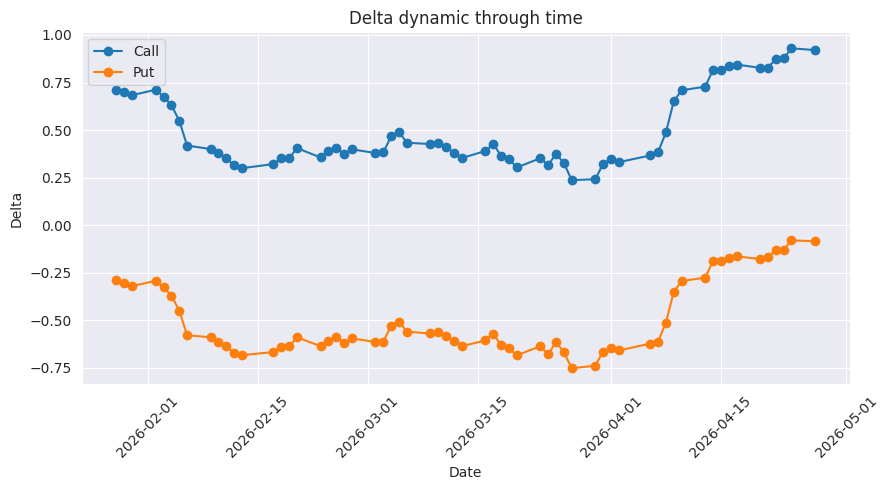

In [71]:
plot_greek_history(
    df_call=df_call,
    df_put=df_put,
    greek="delta",
    title="Delta dynamic through time",
)


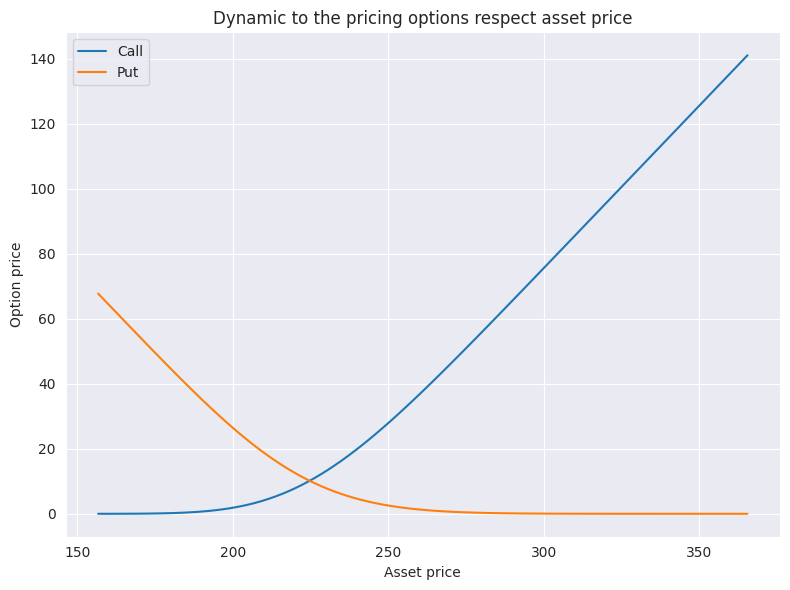

In [72]:
plot_price_sensitivity(
    df_call=df_call,
    df_put=df_put,
    variable="spot_price",
    title="Dynamic to the pricing options respect asset price",
)


# Gamma


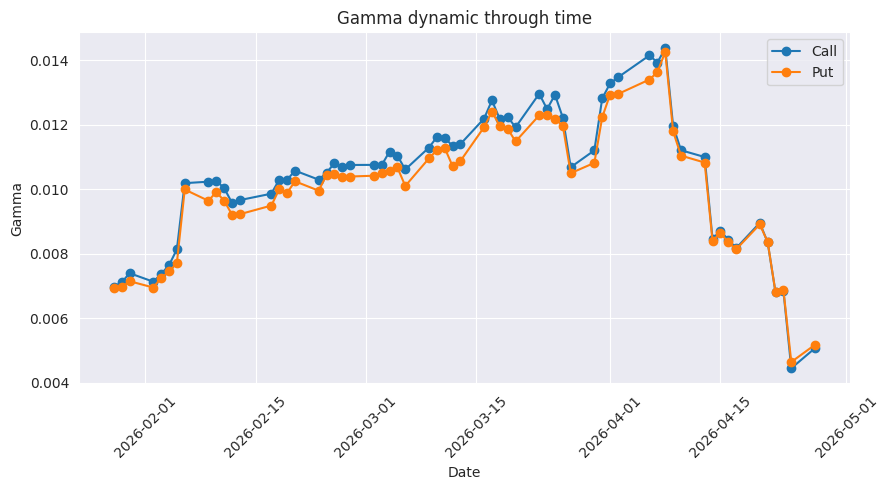

In [73]:
plot_greek_history(
    df_call=df_call,
    df_put=df_put,
    greek="gamma",
    title="Gamma dynamic through time",
)


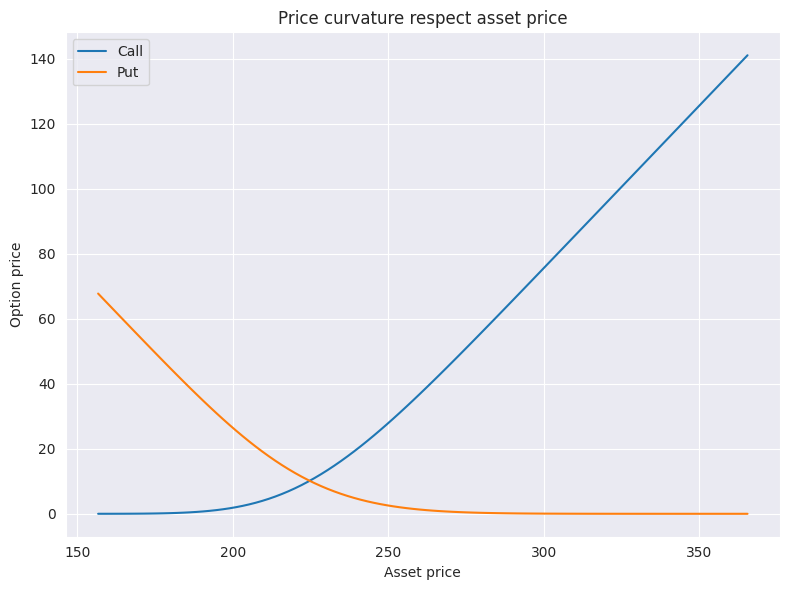

In [74]:
plot_price_sensitivity(
    df_call=df_call,
    df_put=df_put,
    variable="spot_price",
    title="Price curvature respect asset price",
)


# Theta


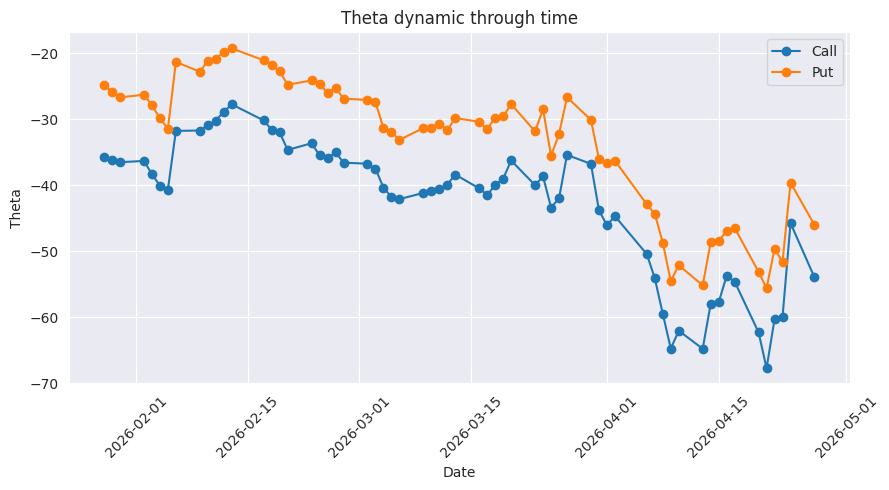

In [75]:
plot_greek_history(
    df_call=df_call,
    df_put=df_put,
    greek="theta",
    title="Theta dynamic through time",
)


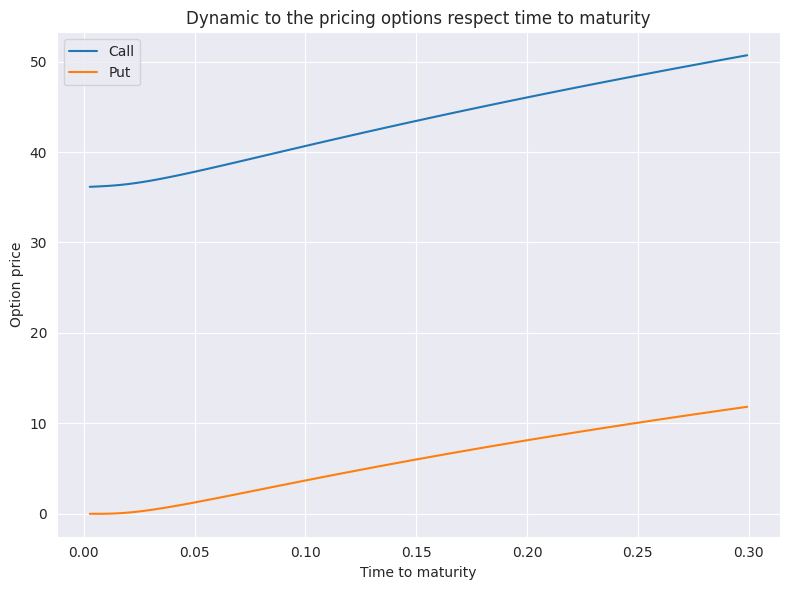

In [76]:
plot_price_sensitivity(
    df_call=df_call,
    df_put=df_put,
    variable="time_to_maturity",
    title="Dynamic to the pricing options respect time to maturity",
)


# Vega


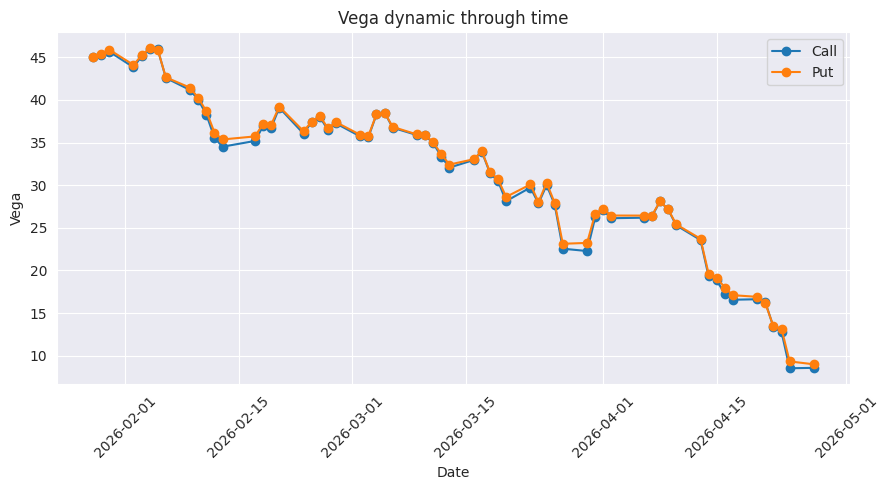

In [77]:
plot_greek_history(
    df_call=df_call,
    df_put=df_put,
    greek="vega",
    title="Vega dynamic through time",
)


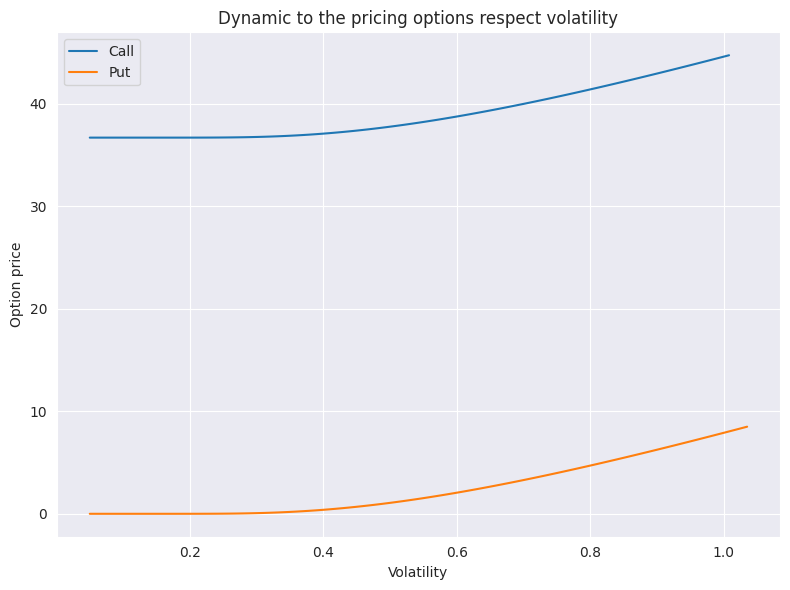

In [78]:
plot_price_sensitivity(
    df_call=df_call,
    df_put=df_put,
    variable="volatility",
    title="Dynamic to the pricing options respect volatility",
)


# Rho


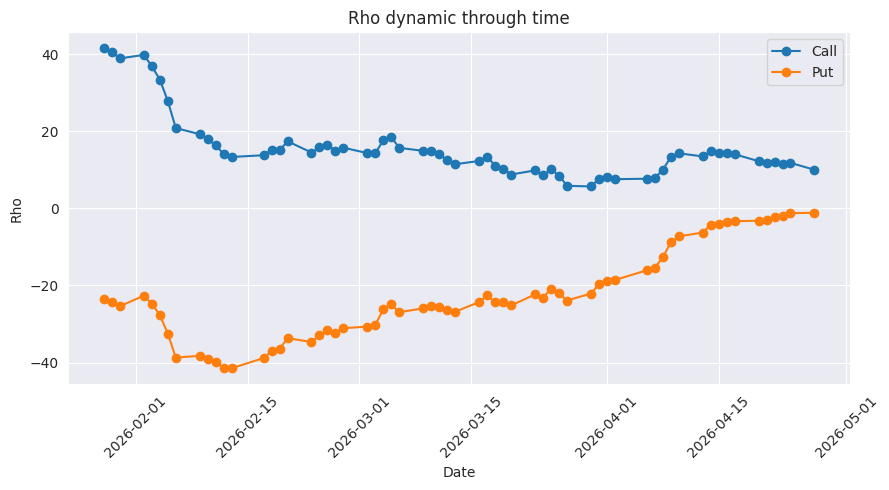

In [79]:
plot_greek_history(
    df_call=df_call,
    df_put=df_put,
    greek="rho",
    title="Rho dynamic through time",
)


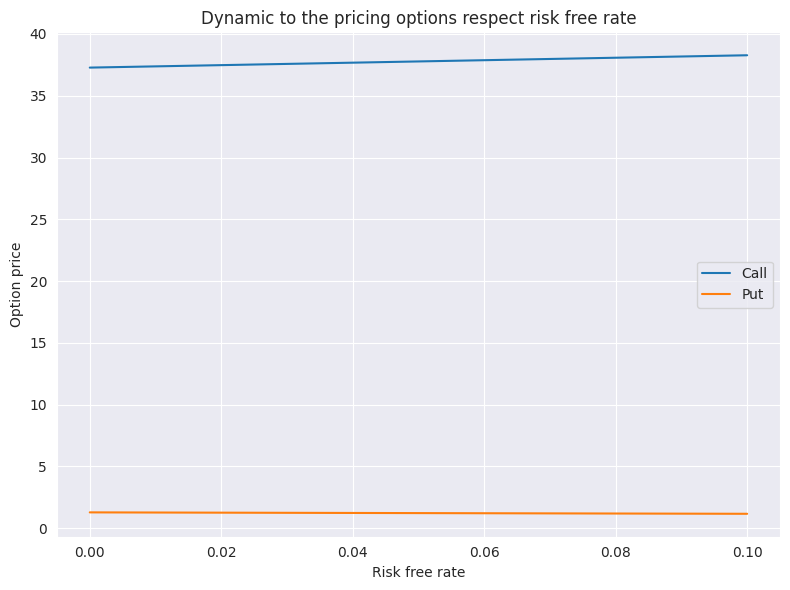

In [80]:
plot_price_sensitivity(
    df_call=df_call,
    df_put=df_put,
    variable="risk_free_rate",
    title="Dynamic to the pricing options respect risk free rate",
)
